<a href="https://colab.research.google.com/github/amoukrim/Python/blob/main/challenge_w2d4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🧼 Missing Values in Dataset:
 overall_rank                    0
country_or_region               0
score                           0
gdp_per_capita                  0
social_support                  0
healthy_life_expectancy         0
freedom_to_make_life_choices    0
generosity                      0
perceptions_of_corruption       0
dtype: int64

📋 Data Types:
 overall_rank                      int64
country_or_region                object
score                           float64
gdp_per_capita                  float64
social_support                  float64
healthy_life_expectancy         float64
freedom_to_make_life_choices    float64
generosity                      float64
perceptions_of_corruption       float64
dtype: object


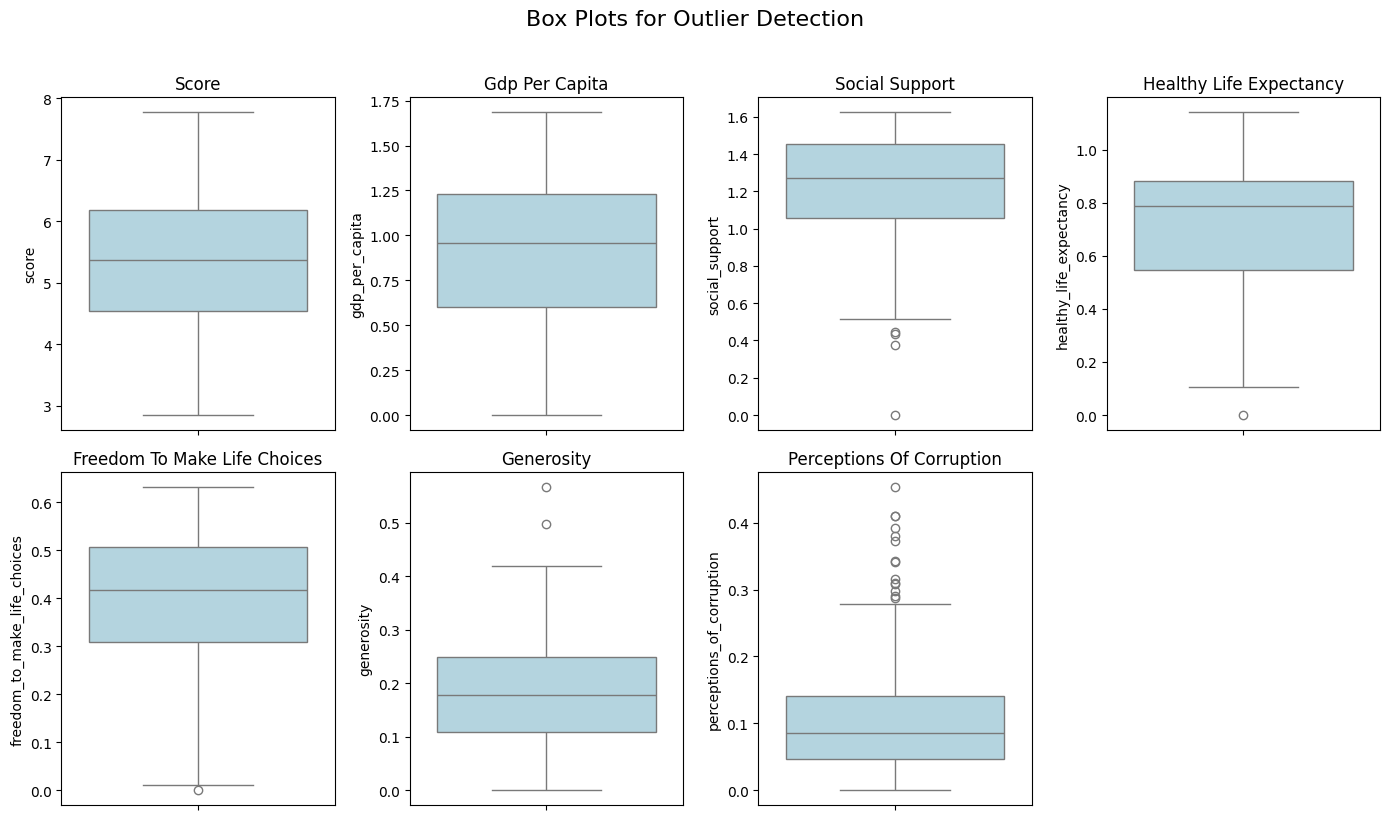

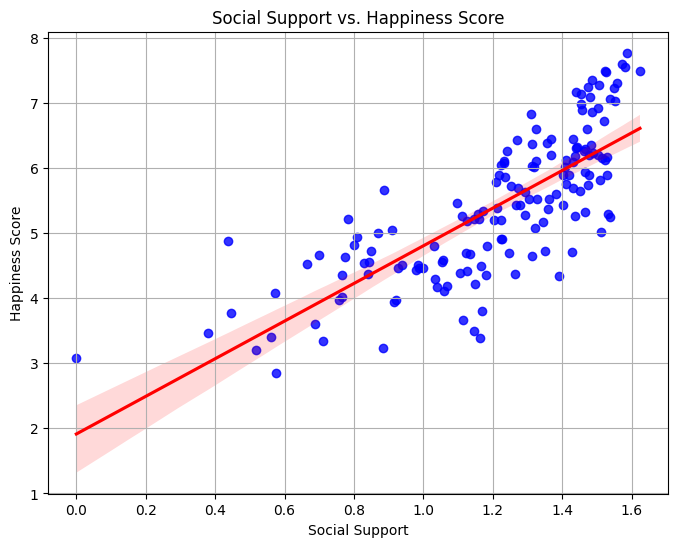

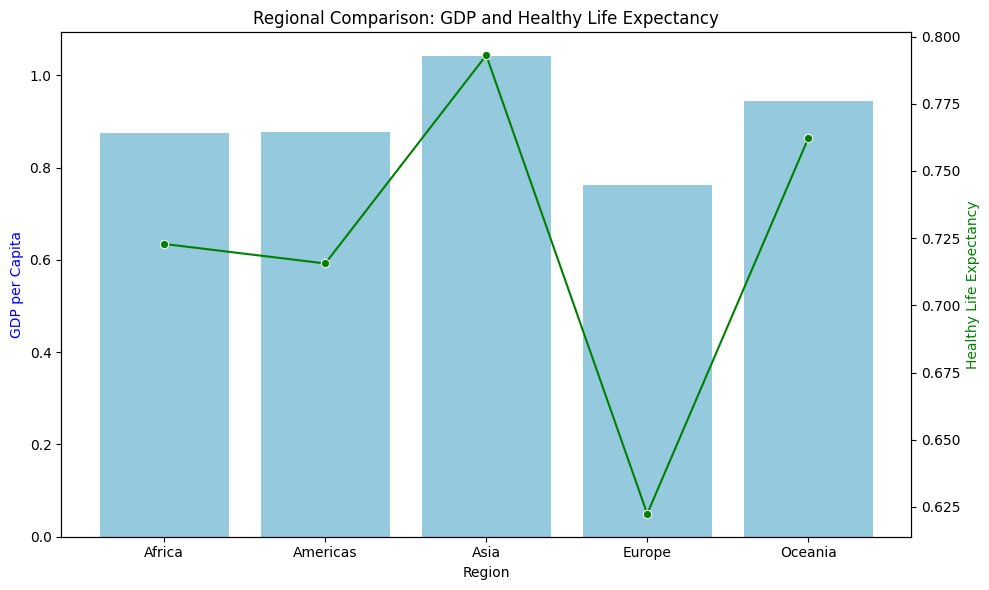

In [2]:
# 📦 Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import random

# 🎯 Step 1: Load the Dataset
# Load the 2019 World Happiness Report CSV file
df = pd.read_csv("/2019.csv")

# Clean and simplify column names for easier access
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# 🔍 Step 2: Basic Data Inspection
# Check for missing values and data types
print("🧼 Missing Values in Dataset:\n", df.isnull().sum())
print("\n📋 Data Types:\n", df.dtypes)

# 📦 Step 3: Outlier Detection using Box Plots
# Select only the numeric columns for visualization
numeric_cols = [
    'score', 'gdp_per_capita', 'social_support',
    'healthy_life_expectancy', 'freedom_to_make_life_choices',
    'generosity', 'perceptions_of_corruption'
]

# Plot box plots for each numeric column to identify outliers
plt.figure(figsize=(14, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(col.replace('_', ' ').title())
plt.suptitle("Box Plots for Outlier Detection", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 📏 Step 4: Normalize Numerical Values (optional for ML or comparison)
# Use Min-Max Scaling to bring values into the [0,1] range
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# 🔗 Step 5: Explore Relationship Between Social Support and Happiness
# Use a scatter plot with a linear regression line
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df,
    x='social_support',
    y='score',
    scatter_kws={'color': 'blue'},     # Blue dots
    line_kws={'color': 'red'}          # Red regression line
)
plt.title("Social Support vs. Happiness Score")
plt.xlabel("Social Support")
plt.ylabel("Happiness Score")
plt.grid(True)
plt.show()

# 🌍 Step 6: Compare GDP and Health Across Regions
# NOTE: This example generates fake regions for demonstration
# In a real project, you should merge this with real regional data

regions = ['Europe', 'Asia', 'Africa', 'Americas', 'Oceania']
df['region'] = [random.choice(regions) for _ in range(len(df))]

# Group data by region and calculate average GDP and life expectancy
region_summary = df.groupby('region').agg({
    'gdp_per_capita': 'mean',
    'healthy_life_expectancy': 'mean'
}).reset_index()

# 📊 Plot GDP as bar and Healthy Life Expectancy as line on the same chart
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for GDP per capita
sns.barplot(data=region_summary, x='region', y='gdp_per_capita', ax=ax1, color='skyblue')
ax1.set_ylabel('GDP per Capita', color='blue')
ax1.set_xlabel('Region')
ax1.set_title('Regional Comparison: GDP and Healthy Life Expectancy')

# Line chart for Healthy Life Expectancy (on second y-axis)
ax2 = ax1.twinx()
sns.lineplot(data=region_summary, x='region', y='healthy_life_expectancy', ax=ax2, marker='o', color='green')
ax2.set_ylabel('Healthy Life Expectancy', color='green')

plt.tight_layout()
plt.show()